# 합성곱 신경망을 사용한 이미지 분류

## 노트북 개요

이 노트북에서는 **합성곱 신경망(CNN, Convolutional Neural Network)**을 사용하여 패션 MNIST 데이터셋의 이미지를 분류하는 방법을 학습합니다.

### 주요 학습 내용:
1. **CNN의 기본 구조** 이해
2. **Conv2D 레이어**와 **MaxPooling2D 레이어**의 역할
3. **패션 MNIST 데이터셋** 로딩 및 전처리
4. **모델 구성**과 **컴파일**
5. **모델 훈련**과 **성능 평가**
6. **예측 결과 시각화**

CNN은 이미지 처리에 특화된 딥러닝 모델로, 이미지의 공간적 특징을 효과적으로 학습할 수 있습니다.

<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/hg-mldl2/blob/main/08-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

In [20]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
import keras
import tensorflow as tf

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

## 1. 환경 설정 및 랜덤 시드 고정

머신러닝 실험에서 **재현 가능한 결과**를 얻기 위해 랜덤 시드를 고정합니다.

### 코드 설명:
- `keras.utils.set_random_seed(42)`: Keras의 모든 랜덤 연산에 대한 시드 설정
- `tf.random.set_seed(42)`: TensorFlow의 랜덤 연산에 대한 시드 설정  
- `tf.config.experimental.enable_op_determinism()`: TensorFlow 연산을 결정적으로 만들어 실행할 때마다 동일한 결과 보장

이러한 설정을 통해 모델 가중치 초기화, 데이터 셔플링 등이 항상 동일하게 수행됩니다.

## 패션 MNIST 데이터 불러오기

In [21]:
import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0

# train_scaled, val_scaled, train_target, val_target = train_test_split(
#     train_scaled, train_target, test_size=0.2, random_state=42)
# 빠른 처리를 위해 60000 -> 6000 으로 변경
# 데이터 10/1 크기로 축소
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled[:6000], train_target[:6000], test_size=0.2, random_state=42)

### 패션 MNIST 데이터셋 설명

**패션 MNIST**는 의류 이미지 분류를 위한 데이터셋으로, 다음과 같은 특징을 갖습니다:

- **이미지 크기**: 28×28 픽셀 (그레이스케일)
- **클래스 수**: 10개 (티셔츠, 바지, 스웨터, 드레스, 코트, 샌달, 셔츠, 스니커즈, 가방, 앵클 부츠)
- **훈련 데이터**: 60,000개
- **테스트 데이터**: 10,000개

### 데이터 전처리 과정:

1. **`train_input.reshape(-1, 28, 28, 1)`**:
   - 2D 이미지를 4D 텐서로 변환 (배치, 높이, 너비, 채널)
   - `-1`: 배치 크기는 자동으로 계산
   - `1`: 그레이스케일 이미지이므로 채널 수는 1

2. **`/ 255.0`**:
   - 픽셀 값을 0~1 범위로 정규화
   - 원래 픽셀 값은 0~255 범위

3. **`train_test_split`**:
   - 훈련 데이터를 80% 훈련용, 20% 검증용으로 분할
   - `random_state=42`: 분할 결과의 재현성 보장

## 합성곱 신경망 만들기

In [22]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28,1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu',
                              padding='same'))

### CNN 모델 구성 - 첫 번째 합성곱 레이어

**Conv2D 레이어**는 CNN의 핵심 구성 요소입니다:

#### 파라미터 설명:
- **`32`**: 필터(커널) 개수
  - 32개의 서로 다른 특징을 학습
  - 각 필터는 이미지에서 특정 패턴(경계, 텍스처 등)을 감지

- **`kernel_size=3`**: 필터 크기 3×3
  - 작은 크기로 세밀한 특징 감지
  - 파라미터 수를 줄여 효율적 학습

- **`activation='relu'`**: ReLU 활성화 함수
  - 음수 값을 0으로 변환하여 비선형성 추가
  - 그래디언트 소실 문제 완화

- **`padding='same'`**: 패딩 적용
  - 입력과 출력 크기를 동일하게 유지
  - 가장자리 정보 손실 방지

#### 출력 형태: (None, 28, 28, 32)
- 28×28 크기는 유지되고, 채널이 1개에서 32개로 증가

In [23]:
model.add(keras.layers.MaxPooling2D(2))

### 최대 풀링(Max Pooling) 레이어

**MaxPooling2D(2)**는 다운샘플링을 수행합니다:

#### 동작 원리:
- **2×2 영역**에서 **최댓값**만 선택
- 이미지 크기를 **절반으로 축소** (28×28 → 14×14)
- **중요한 특징은 보존**하면서 **불필요한 세부사항 제거**

#### 장점:
1. **계산량 감소**: 데이터 크기가 1/4로 줄어들어 연산 속도 향상
2. **과적합 방지**: 세부적인 노이즈를 제거하여 일반화 성능 향상
3. **위치 불변성**: 작은 위치 변화에 강인한 특징 추출
4. **메모리 사용량 감소**: 더 깊은 네트워크 구성 가능

#### 출력 형태: (None, 14, 14, 32)
- 높이와 너비가 28에서 14로 감소
- 채널 수(32)는 유지

In [24]:
model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu',
                              padding='same'))
model.add(keras.layers.MaxPooling2D(2))

### 두 번째 합성곱 블록

**두 번째 Conv2D + MaxPooling2D 블록**은 더 복잡한 특징을 학습합니다:

#### Conv2D(64, kernel_size=(3,3)):
- **필터 개수 증가**: 32개 → 64개
  - 더 많은 특징 맵 생성
  - 더 복잡하고 추상적인 패턴 학습
- **깊어질수록 더 복잡한 특징 학습**:
  - 첫 번째 레이어: 경계, 선분 등 기본 특징
  - 두 번째 레이어: 모양, 텍스처 등 복합 특징

#### 두 번째 MaxPooling2D(2):
- 14×14 → 7×7로 다시 절반 축소
- **계층적 특징 추출**: 점진적으로 공간 해상도 감소, 특징 추상화 증가

#### 출력 형태: (None, 7, 7, 64)
- 공간 해상도: 7×7 (매우 압축된 상태)
- 특징 채널: 64개 (풍부한 특징 정보)

In [25]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

### 완전연결층(Fully Connected Layer) 구성

합성곱 레이어에서 추출된 특징을 **분류 작업**에 사용하기 위해 완전연결층을 구성합니다:

#### Flatten 레이어:
- **3D 특징 맵을 1D 벡터로 변환**: (7, 7, 64) → (3136,)
- 7 × 7 × 64 = 3,136개의 특징을 일렬로 배열

#### Dense(100, activation='relu'):
- **은닉층**: 100개의 뉴런
- **ReLU 활성화**: 비선형성 추가로 복잡한 패턴 학습
- **특징 조합**: 합성곱에서 추출된 특징들을 조합하여 고수준 표현 학습

#### Dropout(0.4):
- **정규화 기법**: 훈련 중 40%의 뉴런을 무작위로 비활성화
- **과적합 방지**: 특정 뉴런에 과도하게 의존하는 것을 방지
- **일반화 성능 향상**: 다양한 조합으로 학습하여 새로운 데이터에 강인

#### Dense(10, activation='softmax'):
- **출력층**: 10개의 클래스에 대한 확률 출력
- **Softmax 활성화**: 모든 클래스 확률의 합이 1이 되도록 정규화
- **다중 클래스 분류**: 가장 높은 확률을 가진 클래스가 예측 결과

In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

### 모델 구조 요약 분석

`model.summary()`는 모델의 전체 구조와 파라미터 정보를 보여줍니다:

#### 주요 정보:
1. **레이어별 출력 형태**: 데이터가 각 레이어를 통과하며 어떻게 변화하는지 확인
2. **파라미터 수**: 각 레이어의 학습 가능한 가중치와 편향의 개수
3. **전체 파라미터**: 모델의 복잡도를 나타내는 지표

#### 파라미터 계산 예시:
- **Conv2D(32, 3×3)**: (3×3×1 + 1) × 32 = 320개
  - 필터 크기 × 입력 채널 + 편향 × 필터 개수
- **Dense(100)**: 3136 × 100 + 100 = 313,700개
  - 입력 크기 × 출력 크기 + 편향

#### 모델 복잡도 확인:
- **Total params**: 전체 파라미터 수
- **Trainable params**: 학습 가능한 파라미터 수  
- **Non-trainable params**: 고정된 파라미터 수 (예: BatchNorm의 통계값)

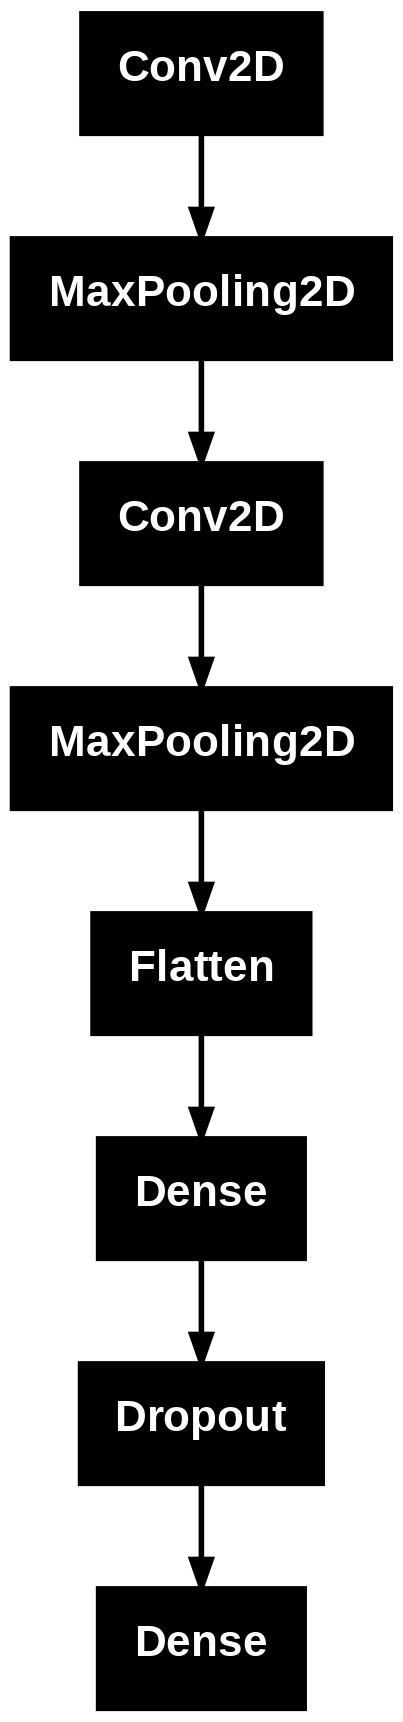

In [27]:
keras.utils.plot_model(model)

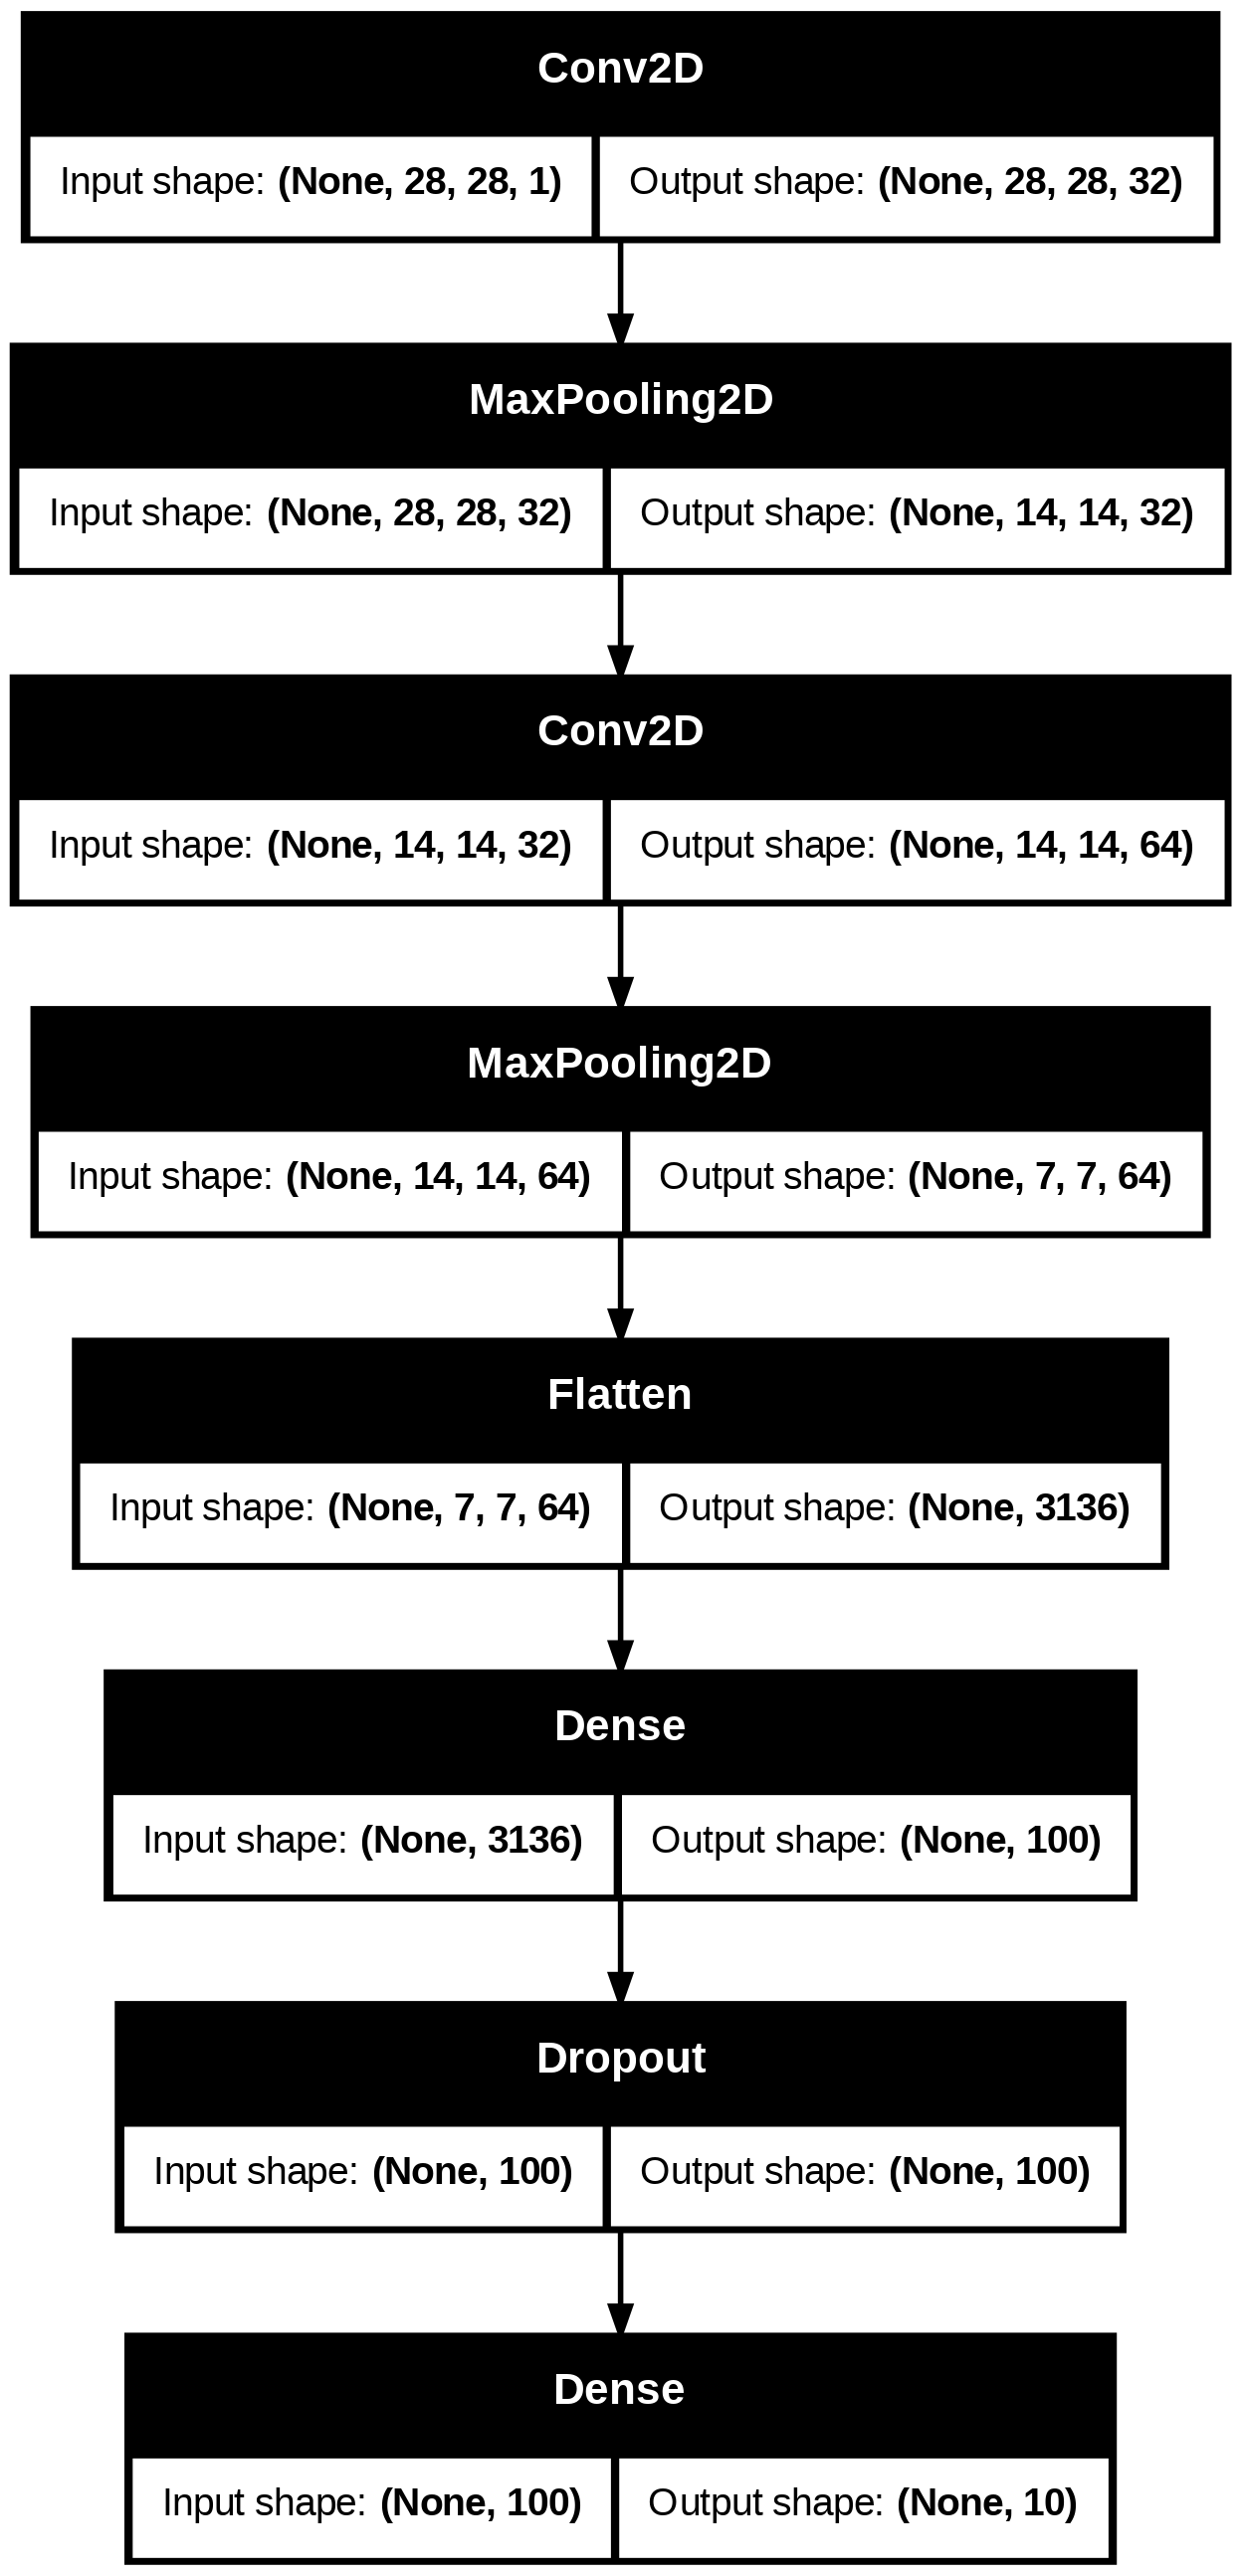

In [28]:
keras.utils.plot_model(model, show_shapes=True)

### 모델 아키텍처 시각화

`keras.utils.plot_model()`을 사용하여 모델 구조를 시각적으로 확인할 수 있습니다:

#### plot_model() 파라미터:
- **기본 시각화**: 레이어 이름과 연결 관계만 표시
- **`show_shapes=True`**: 각 레이어의 입출력 형태까지 함께 표시

#### 시각화의 장점:
1. **구조 이해**: 복잡한 모델의 전체적인 흐름 파악
2. **오류 발견**: 레이어 연결 실수나 차원 불일치 확인
3. **문서화**: 모델 아키텍처를 다른 사람과 공유
4. **디버깅**: 모델 설계 문제 진단

#### CNN 구조의 특징:
- **특징 추출부**: Conv2D + MaxPooling2D 반복
- **분류부**: Flatten + Dense 레이어
- **데이터 흐름**: 공간 해상도는 감소, 채널 수는 증가

## 모델 컴파일과 훈련

In [29]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
              # 현재 텐서플로 버전에서는 최대 풀링에 대한 결정적인 XLA 구현이 없기 때문에
              # enable_op_determinism() 호출로 인해 오류가 발생합니다.
              # 이를 피하기 위해 jit_compile 옵션을 False로 지정합니다.
              # https://github.com/tensorflow/tensorflow/issues/69417
              jit_compile=False)
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5200 - loss: 1.3838 - val_accuracy: 0.7500 - val_loss: 0.6239
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7648 - loss: 0.6451 - val_accuracy: 0.8342 - val_loss: 0.4887
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8065 - loss: 0.5276 - val_accuracy: 0.8317 - val_loss: 0.4796
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8280 - loss: 0.4736 - val_accuracy: 0.8550 - val_loss: 0.4180
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8517 - loss: 0.4256 - val_accuracy: 0.8467 - val_loss: 0.4316
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8539 - loss: 0.3987 - val_accuracy: 0.8600 - val_loss: 0.4041
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8695 - loss: 0.3762 - val_accuracy: 0.8525 - val_loss: 0.4204
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8721 - loss: 0.3514 - val_accuracy: 0.

### 모델 컴파일과 훈련 설정 상세 분석

#### 모델 컴파일 설정:

**`optimizer='adam'`**:
- **Adam 옵티마이저**: 학습률을 자동으로 조절하는 고급 최적화 알고리즘
- **모멘텀 + RMSprop 결합**: 빠른 수렴과 안정적인 학습
- **적응적 학습률**: 파라미터별로 최적의 학습률 적용

**`loss='sparse_categorical_crossentropy'`**:
- **다중 클래스 분류**에 적합한 손실 함수
- **sparse**: 정수 형태의 레이블 사용 (원-핫 인코딩 불필요)
- **categorical_crossentropy**: 확률 분포 간의 차이 측정

**`metrics=['accuracy']`**:
- **정확도 지표**: 올바르게 분류된 샘플의 비율
- 훈련 과정에서 성능 모니터링

**`jit_compile=False`**:
- **XLA 컴파일 비활성화**: TensorFlow의 결정적 동작 보장
- MaxPooling과 관련된 비결정적 동작 방지

#### 콜백 함수 설정:

**ModelCheckpoint**:
- **최고 성능 모델 저장**: 검증 손실이 가장 낮을 때의 모델 저장
- **자동 백업**: 훈련 중단되어도 최적 모델 보존

**EarlyStopping**:
- **조기 종료**: 검증 성능이 개선되지 않으면 훈련 중단
- **`patience=2`**: 2 에포크 동안 개선이 없으면 중단
- **`restore_best_weights=True`**: 최고 성능 시점의 가중치로 복원
- **과적합 방지**: 불필요한 훈련 시간 단축

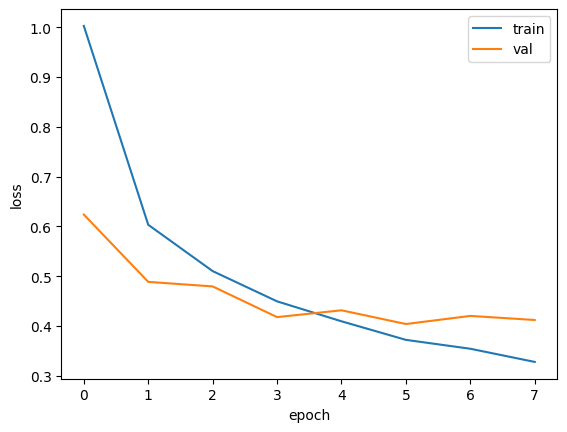

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

### 훈련 과정 시각화 및 분석

**손실 함수 그래프**를 통해 모델의 훈련 과정을 분석할 수 있습니다:

#### 그래프 해석:
1. **훈련 손실(train)**: 파란색 선
   - 에포크가 진행될수록 감소해야 함
   - 모델이 훈련 데이터에 적합해지는 정도

2. **검증 손실(val)**: 주황색 선  
   - 일반화 성능을 나타내는 핵심 지표
   - 훈련 손실과 함께 감소하는 것이 이상적

#### 주요 패턴 분석:
- **정상적인 학습**: 두 손실이 함께 감소
- **과적합 징후**: 훈련 손실은 계속 감소하지만 검증 손실이 증가
- **언더피팅**: 두 손실 모두 높은 수준에서 정체
- **최적 지점**: 검증 손실이 최소가 되는 에포크

#### 조기 종료의 효과:
- **EarlyStopping**: 검증 손실이 더 이상 개선되지 않을 때 자동 중단
- **최적 모델 보존**: 과적합 전 최고 성능 상태로 복원

In [31]:
model.evaluate(val_scaled, val_target)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8611 - loss: 0.3935


[0.404085248708725, 0.8600000143051147]

### 모델 성능 평가

**`model.evaluate()`**는 모델의 최종 성능을 평가합니다:

#### 평가 지표:
1. **검증 손실(Validation Loss)**:
   - 낮을수록 좋음 (0에 가까울수록 완벽)
   - 모델의 예측과 실제 답 간의 차이

2. **검증 정확도(Validation Accuracy)**:
   - 높을수록 좋음 (1.0이 100% 정확도)
   - 올바르게 분류된 샘플의 비율

#### 성능 해석:
- **80-85%**: 기본적인 CNN으로 양호한 성능
- **90% 이상**: 우수한 성능 (더 복잡한 모델 필요할 수 있음)
- **95% 이상**: 매우 우수한 성능

#### 검증 세트의 중요성:
- **훈련 중 보지 않은 데이터**로 평가
- **일반화 성능** 측정
- **과적합 여부** 판단 가능

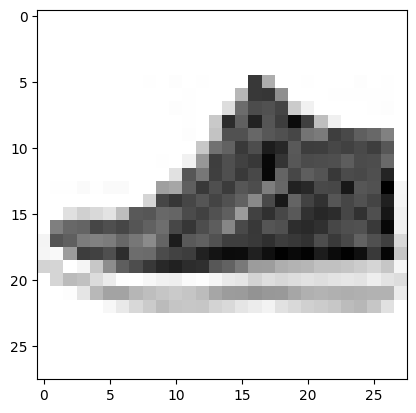

In [32]:
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()

In [43]:
preds = model.predict(val_scaled[0:1])
print(preds)

SyntaxError: incomplete input (ipython-input-43-3361211314.py, line 2)

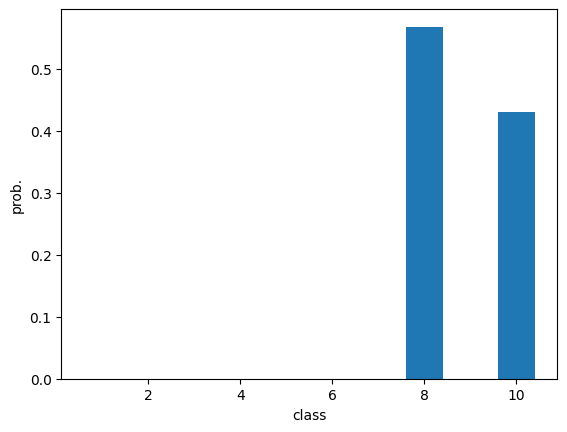

In [34]:
plt.bar(range(1, 11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()

### 예측 결과 시각화 및 분석

#### 개별 샘플 예측 과정:

1. **이미지 확인**: `plt.imshow()`로 실제 이미지 시각화
2. **모델 예측**: `model.predict()`로 각 클래스별 확률 계산  
3. **확률 분포 시각화**: 막대 그래프로 10개 클래스별 확률 표시

#### 예측 확률 해석:
- **Y축**: 각 클래스에 대한 확률 (0~1 범위)
- **X축**: 클래스 번호 (1~10)
- **가장 높은 막대**: 모델이 가장 확신하는 클래스
- **확률 분포**: 모델의 확신 정도 판단 가능

#### 예측 품질 판단:
- **명확한 예측**: 한 클래스의 확률이 압도적으로 높음 (0.8 이상)
- **애매한 예측**: 여러 클래스의 확률이 비슷함
- **잘못된 예측**: 실제 클래스의 확률이 낮음

#### Softmax의 특성:
- **모든 확률의 합 = 1.0**: 정규화된 확률 분포
- **상대적 비교**: 절댓값보다 클래스 간 상대적 크기가 중요

In [35]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
           '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

In [36]:
import numpy as np

print(classes[np.argmax(preds)])

스니커즈


### 최종 예측 결과 해석

#### 클래스 매핑:
패션 MNIST의 10개 클래스는 다음과 같이 정의됩니다:
- **0**: 티셔츠/탑
- **1**: 바지  
- **2**: 풀오버/스웨터
- **3**: 드레스
- **4**: 코트
- **5**: 샌달
- **6**: 셔츠
- **7**: 스니커즈
- **8**: 가방
- **9**: 앵클 부츠

#### 예측 과정:
1. **`np.argmax(preds)`**: 가장 높은 확률을 가진 클래스의 인덱스 반환
2. **`classes[인덱스]`**: 숫자 인덱스를 한글 클래스명으로 변환
3. **최종 결과**: 모델이 예측한 의류 종류 출력

#### 예측 신뢰도 확인:
- **높은 신뢰도**: 최고 확률이 0.8 이상
- **보통 신뢰도**: 최고 확률이 0.5~0.8
- **낮은 신뢰도**: 최고 확률이 0.5 미만 (추가 검토 필요)

In [37]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [38]:
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8489 - loss: 0.4239


[0.430164635181427, 0.8443999886512756]

### 최종 테스트 평가 및 정리

#### 테스트 데이터 평가:
**`model.evaluate(test_scaled, test_target)`**는 모델의 **최종 성능**을 측정합니다:

- **테스트 세트**: 훈련과 검증에 전혀 사용되지 않은 독립적인 데이터
- **진정한 일반화 성능**: 실제 운영 환경에서의 성능 예측
- **공정한 평가**: 모델이 처음 보는 데이터에 대한 객관적 성능

#### 성능 비교:
1. **검증 성능 vs 테스트 성능**: 큰 차이가 없어야 정상
2. **과적합 확인**: 테스트 성능이 현저히 낮으면 과적합 의심
3. **모델 신뢰성**: 일관된 성능은 모델의 안정성을 보장

---

## 학습 요약

### CNN의 핵심 개념:
1. **합성곱 레이어**: 이미지의 공간적 특징 추출
2. **풀링 레이어**: 중요한 정보 보존하며 크기 축소
3. **계층적 학습**: 낮은 레벨부터 높은 레벨 특징까지 단계적 학습

### 모델 구성 전략:
- **특징 추출부**: Conv2D + MaxPooling2D 반복
- **분류부**: Flatten + Dense + Dropout
- **정규화**: 과적합 방지를 위한 Dropout 사용

### 훈련 Best Practices:
- **콜백 활용**: ModelCheckpoint + EarlyStopping
- **성능 모니터링**: 훈련/검증 손실 그래프 분석
- **최종 평가**: 독립적인 테스트 세트로 검증

이러한 CNN 구조는 다양한 이미지 분류 문제에 응용할 수 있는 기본 템플릿입니다.